In [60]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as signal
import os
import sys
import time
sys.path.append(os.path.abspath('..'))
from package import load_rirs, select_latest_rir
from package.utils import create_micsigs 
from package.utils import calculate_ground_truth_doas
import scipy.linalg



base_path = '..'
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acousticScenario = load_rirs(rir_file)


In [ ]:
def create_micsigs_modified(acoustic_scenario, speech_filenames, noise_filenames, duration):
    fs_rir = acoustic_scenario.fs
    if fs_rir != 44100:
        raise ValueError(f"Fout: Sampling frequency moet 44.1 kHz zijn, maar is {fs_rir} Hz.")
    num_mics = len(acoustic_scenario.RIRs_audio[0])
    num_samples = int(duration * fs_rir)
    
    speech_component = np.zeros((num_samples, num_mics))
    noise_component = np.zeros((num_samples, num_mics))

    for src_idx, filename in enumerate(speech_filenames):
        audio, fs_src = sf.read(filename)
        if fs_src != fs_rir:
            new_len = int(len(audio) * fs_rir / fs_src)
            audio = signal.resample(audio, new_len)
        
        for mic_idx in range(num_mics):
            rir = acoustic_scenario.RIRs_audio[:, mic_idx, src_idx]
            filtered = signal.fftconvolve(audio, rir, mode='full')
            
      
            
            L = min(len(filtered), num_samples)
            speech_component[:L, mic_idx] += filtered[:L]

# RUIS 

    if noise_filenames and len(noise_filenames) > 0 and acoustic_scenario.RIRs_noise is not None:
        for src_idx, filename in enumerate(noise_filenames):
            if not filename: continue
          
            audio, fs_src = sf.read(filename)
            
            if fs_src != fs_rir:
                audio = signal.resample(audio, int(len(audio) * fs_rir / fs_src))
                
            for mic_idx in range(num_mics):
  
                rir = acoustic_scenario.RIRs_noise[:, mic_idx, src_idx]
                filtered = signal.fftconvolve(audio, rir, mode='full')
                
                L = min(len(filtered), num_samples)
                noise_component[:L, mic_idx] += filtered[:L]
    else:
        print(" geen ruis-RIRs gevonden")

    speech_mic1 = speech_component[:, 0]
    vad = np.abs(speech_mic1) > np.std(speech_mic1) * 1e-3
    active_speech = speech_mic1[vad]
    Ps = np.var(active_speech) if len(active_speech) > 0 else 0
    Pn_target = 0.1 * Ps
    white_noise = np.random.normal(0, np.sqrt(Pn_target), (num_samples, num_mics))
       
    noise_component += white_noise
    Pn_actual = np.var(noise_component[:, 0])
    
    
    snr_mic1 = 10 * np.log10(Ps / Pn_actual)
    print(f"SNR in de eerste microfoon: {snr_mic1:.2f} dB")
    

    mic = speech_component + noise_component

    
    return mic, speech_component, noise_component, snr_mic1, vad

In [62]:
def music_wideband(micsigs, fs, acoustic_scenario):
    L = 1024
    overlap = L // 2
    
    stft_list = []
    for m in range(micsigs.shape[1]):
        freqs, _, Zxx = signal.stft(micsigs[:, m], fs=fs, window='hann', nperseg=L, noverlap=overlap)
        stft_list.append(Zxx)
    stft_data = np.stack(stft_list, axis=0) # Shape: (M, nF, nT)
    
    M, nF, nT = stft_data.shape
    c = 343.0
    num_audio = acoustic_scenario.audioPos.shape[0] if acoustic_scenario.audioPos is not None else 0
    num_noise = acoustic_scenario.noisePos.shape[0] if acoustic_scenario.noisePos is not None else 0
    Q = num_audio + num_noise
    
    angles = np.arange(0, 180.5, 0.5)
    rads = np.radians(angles)
    
    mics_centered = acoustic_scenario.micPos - np.mean(acoustic_scenario.micPos, axis=0)
    px = mics_centered[:, 0].reshape(-1, 1)
    py = mics_centered[:, 1].reshape(-1, 1)
    
    valid_indices = range(1, L // 2)
    pseudospectra = []
    
    for k in valid_indices:
        Y = stft_data[:, k, :]
        Ryy = (Y @ Y.conj().T) / nT
        _, eigvecs = np.linalg.eigh(Ryy)
        En = eigvecs[:, :M-Q] 
        
        omega = 2 * np.pi * freqs[k]
        taus = (px * np.sin(rads) + py * np.cos(rads)) / c 
        A = np.exp(-1j * omega * taus)
        
        denom = np.sum(np.abs(En.conj().T @ A)**2, axis=0)
        p_theta = 1.0 / denom
        pseudospectra.append(p_theta)
        
    pseudospectra = np.array(pseudospectra) 
    
    log_p = np.log(pseudospectra)
    p_geom = np.exp(np.mean(log_p, axis=0))
    spectrum_geom_db = 10 * np.log10(p_geom / np.max(p_geom))
    
    peaks_indices, _ = signal.find_peaks(spectrum_geom_db)

    sorted_peak_indices = peaks_indices[np.argsort(spectrum_geom_db[peaks_indices])][-Q:]
    estimated_doas = np.sort(angles[sorted_peak_indices])

    ps_ind_db = 10 * np.log10(pseudospectra / np.max(pseudospectra, axis=1, keepdims=True))

    return angles, ps_ind_db, spectrum_geom_db, estimated_doas, stft_data


> Voor de GSC in individuele frequentiebins vervangen we de standaard DAS beamformer door een 'Filter-and-Sum Beamformer' (FAS BF). We maken vooraf een Look-Up Table aan met stuurvectoren door de DFT van de RIRs te normaliseren ten opzichte van de eerste microfoon:
> 
> 
> $$h(\omega,\theta)=\frac{a(\omega,\theta)}{a_{1}(\omega,\theta)}$$
> 
> 
> De FAS BF definiëren we vervolgens als:
> 
> 
> $$w_{FAS}(\omega,\theta)=\frac{h(\omega,\theta)}{h^{H}(\omega,\theta)h(\omega,\theta)}$$
> 
> 
> En de Blocking Matrix wordt zodanig gedefinieerd dat:
> 
> 
> $$B(\omega,\theta)h(\omega,\theta)=0$$
> 


In [ ]:
          

def get_target_rir_from_scenario(scenario, source_index=0):
  
    if not hasattr(scenario, 'RIRs_audio') or scenario.RIRs_audio is None:
        raise ValueError("Kan 'RIRs_audio' niet vinden in het scenario!")
        
    # Snijd de 3D matrix (samples, mics, sources) af op de gewenste source_index (0)
    # Dit geeft een 2D matrix (samples, mics) terug wat de LUT-builder nodig heeft
    target_rir = scenario.RIRs_audio[:, :, source_index]
    
    return target_rir
def build_lut_for_target(target_rir, L=1024):
 
    n_bins = L // 2 + 1
    M_mics = target_rir.shape[1]
    
    H_omega = np.fft.rfft(target_rir, n=L, axis=0) #vector hoe die specifieke frequentie van de bron naar alle M microfoons reist.
    
    W_FAS = np.zeros((n_bins, M_mics), dtype=complex)
    B_matrix = np.zeros((n_bins, M_mics - 1, M_mics), dtype=complex)
    
    for k in range(n_bins):
        h_k = H_omega[k, :].reshape(M_mics, 1) #2D kolom
        
        # Normalizeer naar Mic 1 (index 0)
        eps = 1e-12
        A_1 = h_k[0, 0] 
        if np.abs(A_1) > eps:
            h_k = h_k /( A_1)
        else:
            h_k = h_k /( A_1+eps)
            
        # FAS Beamformer
        denom = (h_k.conj().T @ h_k)[0, 0] #vermogen stuurvector, complex geconjugeerde
        if np.abs(denom) > eps:
            W_FAS[k, :] = (h_k / denom).flatten() #signaal uit target richting perfect doorlaten,2Dkolom naar 1Dlijst
        else:
            W_FAS[k, :] = np.ones(M_mics) / M_mics #zoals das want je weet niet hoe te filteren,  ongewogen gem
            
        # Blocking Matrix
        Z = scipy.linalg.null_space(h_k.conj().T) #loodrecht op target
        if Z.shape[1] > 0:
            B_matrix[k, :, :] = Z.conj().T #binnenkomende audio maal dit -> alles wat uit target richting komt 0, alleen nog ruisreferenties
            #terug complex geconjugeerde zodat in vorm Bh=0 ipv h^H Z=0
    return W_FAS, B_matrix

def build_lut_all_angles(all_rirs_dict, angles, L=1024):
    
    lut = {}
    for angle in angles:
        rir = all_rirs_dict[angle]
        # Hergebruik  voor 1 specifieke RIR
        W_FAS, B = build_lut_for_target(rir, L=L)
        lut[angle] = (W_FAS, B)
    return lut

Deze implementatie transformeert tijddomein signalen met een STFT naar het frequentiedomein (met 50% overlap), voert in elke bin de GSC uit met de LUT, en zet de output via inverse DFT (WOLA) weer terug naar het tijdsdomein

In [64]:
def gsc_fd(scenario, estimated_doa, lut, precomputed_speech, precomputed_noise, mu=0.1):
    speech = precomputed_speech
    noise = precomputed_noise
    mic = speech + noise

    lut_angles = np.array(list(lut.keys()))
    closest_angle = lut_angles[np.argmin(np.abs(lut_angles - estimated_doa))]
    W_FAS_lut, B_lut = lut[closest_angle]
    
    print(f"   [GSC] Gebruikte DOA uit LUT: {closest_angle}° (geschat: {estimated_doa:.1f}°)")

    #snr_in = 10 * np.log10(np.var(speech[:, 0]) / np.var(noise[:, 0]))

    vad = np.abs(speech[:, 0]) > (np.std(speech[:, 0]) * 0.1)
    
    N_samples, M_mics = mic.shape
    L = 1024
    overlap = L // 2
    window_sqrthann = np.sqrt(signal.windows.hann(L, sym=False))
  

    _, _, Zxx_mix = signal.stft(mic.T, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    _, _, Zxx_tar = signal.stft(speech.T, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    _, _, Zxx_int = signal.stft(noise.T, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    
    nF, nT = Zxx_mix.shape[1], Zxx_mix.shape[2]

    vad_frames = np.zeros(nT) #lengte totaal aantal tijdframes in stft
    samples_per_frame = L - overlap #schuiven niet met volledige venster op door overlap
    for n in range(nT):
        start_idx = n * samples_per_frame
        end_idx = start_idx + L
        if end_idx <= N_samples: #anders buiten audiobestand
            vad_frames[n] = 1 if np.mean(vad[start_idx:end_idx]) > 0.5 else 0

    actieve_frames = np.sum(vad_frames)
    percentage_spraak = (actieve_frames / nT) * 100
    percentage_adaptatie = 100 - percentage_spraak
    print(f"  Spraak in {percentage_spraak:.1f}% van de frames | Filter leert in {percentage_adaptatie:.1f}% van de tijd.")

    E_out_mix = np.zeros((nF, nT), dtype=complex)
    E_out_tar = np.zeros((nF, nT), dtype=complex) 
    E_out_int = np.zeros((nF, nT), dtype=complex) 
    FAS_out   = np.zeros((nF, nT), dtype=complex) 
    FAS_out_tar = np.zeros((nF, nT), dtype=complex)
    FAS_out_int = np.zeros((nF, nT), dtype=complex)
    eps = 1e-8
    
    for k in range(nF):
        w_fas = W_FAS_lut[k, :]
        B_k = B_lut[k, :, :]
        w_nlms = np.zeros((M_mics - 1,), dtype=complex)
        
        for n in range(nT):
            x_mix = Zxx_mix[:, k, n] #binnenkomende mic signalen
            x_tar = Zxx_tar[:, k, n]
            x_int = Zxx_int[:, k, n]
            
            y_fas_mix = np.vdot(w_fas, x_mix) #output fas
            u_mix = B_k @ x_mix #mic signalen maal blocking matrix: spraak geblokkeerd want er loodrecht op -> ruisreferenties
            e_mix = y_fas_mix - np.vdot(w_nlms, u_mix) #target - geschatte ruissignaal
            E_out_mix[k, n] = e_mix #later inverse stft voor audio 
            FAS_out[k, n] = y_fas_mix
            
            
            y_fas_tar = np.vdot(w_fas, x_tar)
            FAS_out_tar[k, n] = y_fas_tar
            u_tar = B_k @ x_tar
            E_out_tar[k, n] = y_fas_tar - np.vdot(w_nlms, u_tar) 

            y_fas_int = np.vdot(w_fas, x_int)
            FAS_out_int[k, n] = y_fas_int
            u_int = B_k @ x_int
            E_out_int[k, n] = y_fas_int - np.vdot(w_nlms, u_int) 

            if vad_frames[n] == 0:
                power = np.vdot(u_mix, u_mix).real #vermogen ruisreferenties voor stabiele leerstap
                w_nlms += mu * u_mix * np.conj(e_mix) / (power + eps) #grotere aanpassingen indien nog veel ruis in e
#richting van aanpassing: correlatie tussen ruisreferentie u en resterende fout e (verbeterde signaal), mogen niet fel op elkaar lijken

    _, gsc_out_mix = signal.istft(E_out_mix, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    _, fas_out_time = signal.istft(FAS_out, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    _, out_tar = signal.istft(E_out_tar, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    _, out_int = signal.istft(E_out_int, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    _, fas_tar_time = signal.istft(FAS_out_tar, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    _, fas_int_time = signal.istft(FAS_out_int, fs=scenario.fs, window=window_sqrthann, nperseg=L, noverlap=overlap)
    return gsc_out_mix[:N_samples], mic, fas_out_time[:N_samples], out_tar[:N_samples], out_int[:N_samples], speech, noise, fas_tar_time[:N_samples], fas_int_time[:N_samples]


Om de bereikte performantie aan te tonen en te kwantificeren, maken we gebruik van de Signal-to-Interference Ratio (SIR). De SIR kwantificeert de bijdrage van het gewenste signaal ten opzichte van het interferentiesignaal

In [65]:
def compute_sir(y, x1, x2, groundTruth):
    """
    Compute the signal-to-interference ratio for two sources (one target source
    and one interfering source). The script takes into account possible
    switches between which source is the target and which one is the
    interference. The script assumes there is access to each source's
    contribution in the beamformer output.

    Parameters
    ----------
    -y : [N x 1] np.ndarray[float]
        Actual beamformer output signal (`N` is the number of samples).
    -x1 : [N x 1] np.ndarray[float]
        Beamformer output attributed to source 1.
    -x2 : [N x 1] np.ndarray[float]
        Beamformer output attributed to source 2.
    -groundTruth : [N x 1] np.ndarray[int (0 or 1) or float (0. or 1.)]
        Array indicating, for each sample,
        which source is the target: 1=x1, 0=x2.

    Returns
    -------
    -sir : 
    """
    # Sanity check (check whether `y = x1 + x2` based on RMSE of residual)
    if np.sqrt(np.sum((y - x1 - x2) ** 2)) / np.sqrt(np.sum(y ** 2)) > 0.01:
        print('/!\ Something is wrong, `y` should be the sum of `x1` and `x2`.')  
        print('SIR can not be computed -- Returning NaN.')  
        sir = np.nan
    # Input check
    elif np.sum(groundTruth) + np.sum(1 - groundTruth) != len(groundTruth):
        print('/!\ `groundTruth` vector is not binary.')
        print('SIR can not be computed')  
        sir = np.nan
    else:
        sir = 10 * np.log10(
            np.var(x1 * groundTruth + x2 * (1 - groundTruth)) /\
                np.var(x2 * groundTruth + x1 * (1 - groundTruth))
        )

    return sir

<>:27: SyntaxWarning: invalid escape sequence '\ '
<>:32: SyntaxWarning: invalid escape sequence '\ '
<>:27: SyntaxWarning: invalid escape sequence '\ '
<>:32: SyntaxWarning: invalid escape sequence '\ '
C:\Users\piete\AppData\Local\Temp\ipykernel_35188\1998567044.py:27: SyntaxWarning: invalid escape sequence '\ '
  print('/!\ Something is wrong, `y` should be the sum of `x1` and `x2`.')
C:\Users\piete\AppData\Local\Temp\ipykernel_35188\1998567044.py:32: SyntaxWarning: invalid escape sequence '\ '
  print('/!\ `groundTruth` vector is not binary.')


SNR in de eerste microfoon: 3.72 dB
[DOA] MUSIC detecteert bronnen op: [ 48.  137.5]°
      Gekozen Target DOA (dichtst bij 90°): 48.0°
   [GSC] Gebruikte DOA uit LUT: 48.0° (geschat: 48.0°)
  Spraak in 53.5% van de frames | Filter leert in 46.5% van de tijd.
Input SIR (Mic 1):    2.55 dB
FAS Output SIR:       4.07 dB
GSC Output SIR:       5.73 dB
Netto Verbetering:    3.18 dB


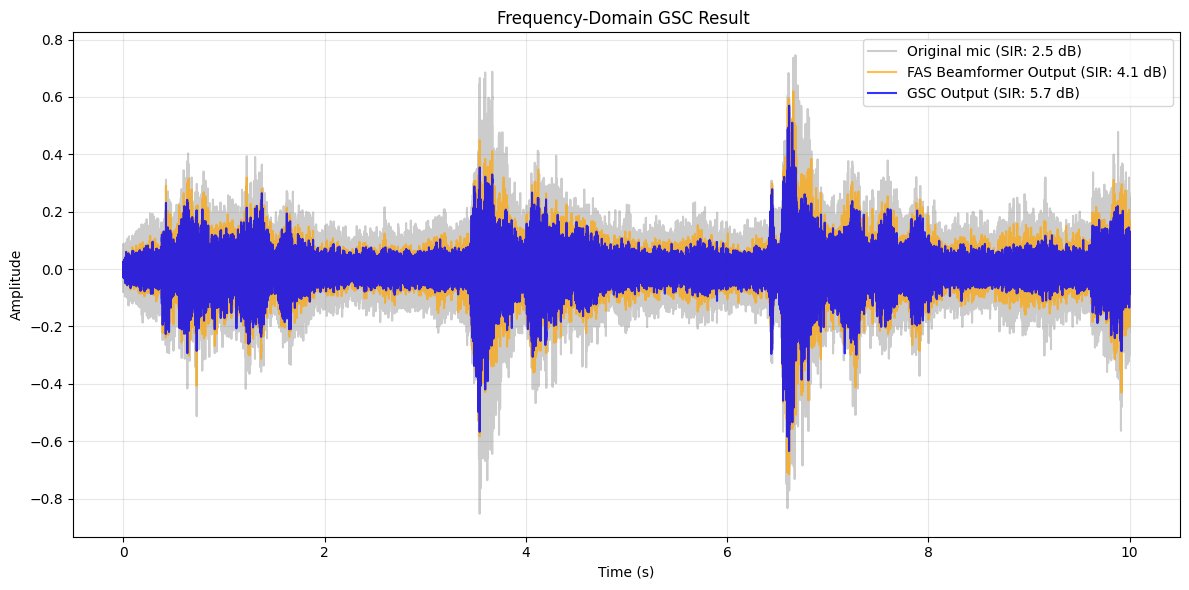

In [59]:
import soundfile as sf
import IPython.display as ipd
import numpy as np

sys.path.append(os.path.abspath('..'))
base_path = '..'
rirs_folder = os.path.join(base_path, 'rirs')
latest_rir = select_latest_rir(rirs_folder)
scenario = load_rirs(latest_rir)

spraak_pad = [os.path.join(base_path, "sound_files", "speech1.wav")]
ruis_pad = [os.path.join(base_path, "sound_files", "Babble_noise1.wav")] 

mic, speech, noise,_,_ = create_micsigs_modified(
    scenario, spraak_pad, ruis_pad, duration=10.0
)

_, _, _, est_doas, _ = music_wideband(mic, scenario.fs, scenario)

target_doa_est = est_doas[np.argmin(np.abs(est_doas - 90.0))]

print(f"[DOA] MUSIC detecteert bronnen op: {est_doas}°")
print(f"      Gekozen Target DOA (dichtst bij 90°): {target_doa_est:.1f}°")


target_rir = get_target_rir_from_scenario(scenario, source_index=0)
W_FAS, B_matrix = build_lut_for_target(target_rir, L=1024)


mijn_lut = {target_doa_est: (W_FAS, B_matrix)}



gsc_out_mix, _,  fas_out_time, out_tar, out_int, speech_out, noise_out, fas_tar, fas_int = gsc_fd(
    scenario=scenario, 
    estimated_doa=target_doa_est, 
    lut=mijn_lut, 
    precomputed_speech=speech, 
    precomputed_noise=noise, 
    mu=0.1  
)

# Omdat de bron hele 10 seconden niet beweegt 
# is de 'ground_truth' array  een reeks met enen
ground_truth = np.ones(len(mic), dtype=int)

sir_in = compute_sir(mic[:, 0], speech[:, 0], noise[:, 0], ground_truth)
sir_fas = compute_sir(fas_out_time, fas_tar, fas_int, ground_truth)
sir_out = compute_sir(gsc_out_mix, out_tar, out_int, ground_truth)


print(f"Input SIR (Mic 1):    {sir_in:.2f} dB")
print(f"FAS Output SIR:       {sir_fas:.2f} dB")
print(f"GSC Output SIR:       {sir_out:.2f} dB")
print(f"Netto Verbetering:    {sir_out - sir_in:.2f} dB")


t = np.arange(len(mic)) / scenario.fs
plt.figure(figsize=(12, 6))
plt.plot(t, mic[:, 0], color='gray', alpha=0.4, label=f'Original mic (SIR: {sir_in:.1f} dB)')
plt.plot(t, fas_out_time, color='orange', alpha=0.7, label=f'FAS Beamformer Output (SIR: {sir_fas:.1f} dB)')
plt.plot(t, gsc_out_mix, color='blue', alpha=0.8, label=f'GSC Output (SIR: {sir_out:.1f} dB)')
plt.title(f"Frequency-Domain GSC Result ")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




def normalize(audio):
    return audio / (np.max(np.abs(audio)) + 1e-9)

mic_audio = normalize(mic[:, 0])
fas_audio = normalize(fas_out_time)
gsc_audio = normalize(gsc_out_mix)

sf.write("Demo_01_Origineel_Mic1.wav", mic_audio, scenario.fs)
sf.write("Demo_02_FAS_Only.wav", fas_audio, scenario.fs)
sf.write("Demo_03_Volledige_GSC.wav", gsc_audio, scenario.fs)

In dit experiment testen we een tijdsafhankelijk akoestisch scenario. We kiezen 5 posities voor de bron (180∘ tot 90∘) en 5 voor ruis (90∘ tot 0∘), met posities die elke 10 seconden wijzigen. We evalueren dit onder zowel anechoïsche (T60=0s) als reverberante (T60=1s) omstandigheden. Uiteindelijk plotten we de SIR waarden in de microfoonsignalen vergeleken met ná de GSC filtering


STARTING SCENARIO: ANECHOIC (T60=0s)

--- Segment 1/5 | Tijd: 0s tot 10s | Bestand: 160_20_no_reverb.pkl ---
   [DOA] MUSIC schatting: 157.0°
   [GSC] Gebruikte DOA uit LUT: 160.0° (geschat: 157.0°)
  Spraak in 49.8% van de frames | Filter leert in 50.2% van de tijd.
   [SIR] Prestaties per seconde:
         Sec 01: Input SIR =   8.3 dB  -->  GSC Output SIR =  17.6 dB
         Sec 02: Input SIR =   4.4 dB  -->  GSC Output SIR =  17.3 dB
         Sec 03: Input SIR =   7.2 dB  -->  GSC Output SIR =  15.0 dB
         Sec 04: Input SIR =  14.8 dB  -->  GSC Output SIR =  22.0 dB
         Sec 05: Input SIR =   0.4 dB  -->  GSC Output SIR =   1.6 dB
         Sec 06: Input SIR =   6.3 dB  -->  GSC Output SIR =  20.0 dB
         Sec 07: Input SIR =   3.9 dB  -->  GSC Output SIR =  21.1 dB
         Sec 08: Input SIR =   7.4 dB  -->  GSC Output SIR =  25.1 dB
         Sec 09: Input SIR =   1.5 dB  -->  GSC Output SIR =  20.7 dB
         Sec 10: Input SIR =  12.1 dB  -->  GSC Output SIR =  25.6 d

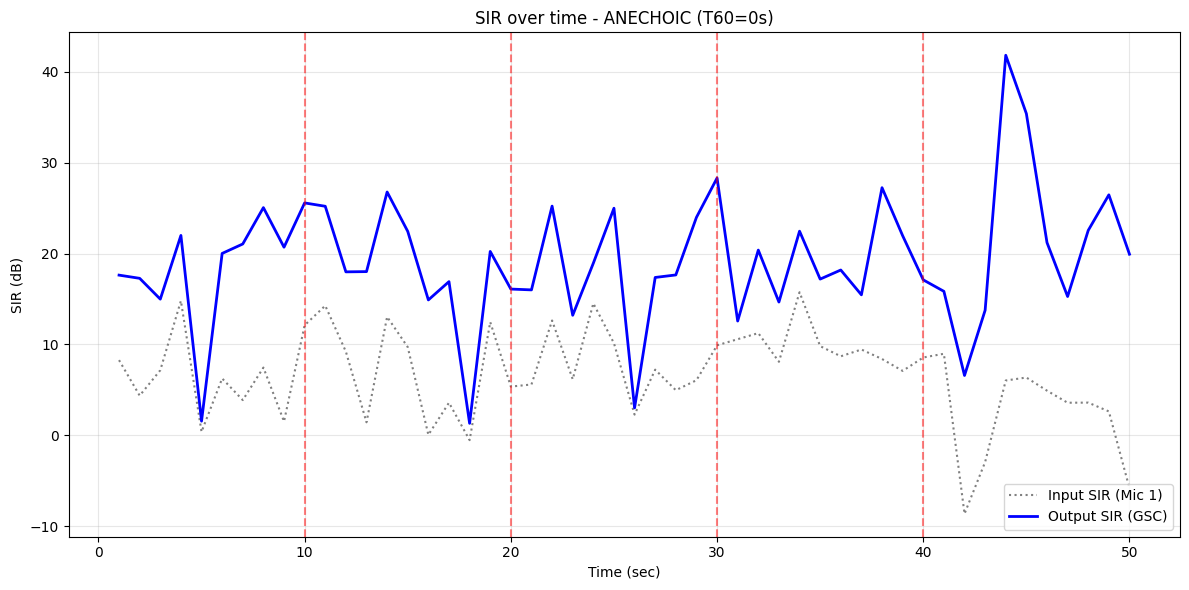


STARTING SCENARIO: REVERBERANT (T60=1s)

--- Segment 1/5 | Tijd: 0s tot 10s | Bestand: 160_20_reverb.pkl ---
   [DOA] MUSIC schatting: 157.0°
   [GSC] Gebruikte DOA uit LUT: 160.0° (geschat: 157.0°)
  Spraak in 64.4% van de frames | Filter leert in 35.6% van de tijd.
   [SIR] Prestaties per seconde:
         Sec 01: Input SIR =   6.8 dB  -->  GSC Output SIR =  11.0 dB
         Sec 02: Input SIR =   5.9 dB  -->  GSC Output SIR =  10.2 dB
         Sec 03: Input SIR =   9.1 dB  -->  GSC Output SIR =  14.3 dB
         Sec 04: Input SIR =  12.7 dB  -->  GSC Output SIR =  18.2 dB
         Sec 05: Input SIR =   3.4 dB  -->  GSC Output SIR =   9.3 dB
         Sec 06: Input SIR =   8.7 dB  -->  GSC Output SIR =  14.1 dB
         Sec 07: Input SIR =   4.1 dB  -->  GSC Output SIR =  10.6 dB
         Sec 08: Input SIR =   5.7 dB  -->  GSC Output SIR =  10.5 dB
         Sec 09: Input SIR =   2.4 dB  -->  GSC Output SIR =   9.1 dB
         Sec 10: Input SIR =  11.1 dB  -->  GSC Output SIR =  14.5 d

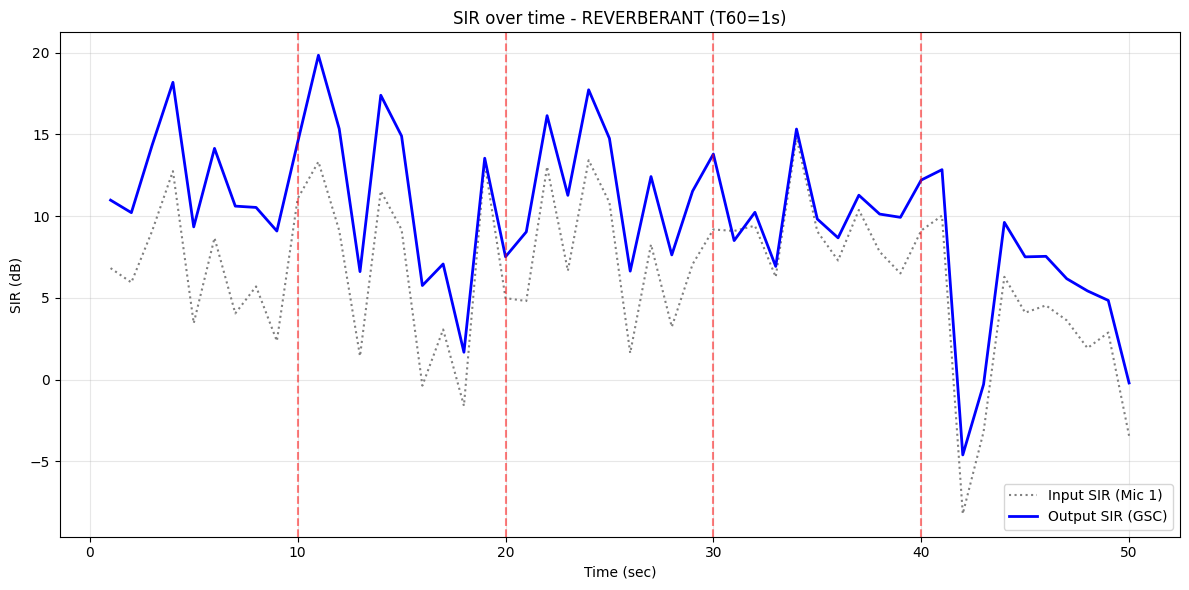

In [ ]:
import os
import time
import numpy as np
import scipy.signal as signal
import soundfile as sf
import matplotlib.pyplot as plt


current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))

fs = 44100
segment_duration = 10.0 
segment_samples = int(fs * segment_duration)

t_dry, _ = sf.read(os.path.join(parent_dir, "sound_files", "part1_track1_dry.wav"))
i_dry, _ = sf.read(os.path.join(parent_dir, "sound_files", "part1_track2_dry.wav"))

# Normalisatie om clipping te voorkomen
t_dry = t_dry / np.max(np.abs(t_dry)) * 0.9
i_dry = i_dry / np.max(np.abs(i_dry)) * 0.9


for use_reverb in [False, True]:
    
    reverb_label = "REVERBERANT (T60=1s)" if use_reverb else "ANECHOIC (T60=0s)"
    
    if not use_reverb:
        rir_files = ["160_20_no_reverb.pkl", "140_40_no_reverb.pkl", "120_60_no_reverb.pkl", "100_40_no_reverb.pkl", "95_85_no_reverb.pkl"]
    else:
        rir_files = ["160_20_reverb.pkl", "140_40_reverb.pkl", "120_60_reverb.pkl", "100_40_reverb.pkl", "95_85_reverb.pkl"]

    all_rirs_dict = {}
    lut_angles_list = []
    
    for rir_file in rir_files:
        scenario_tmp = load_rirs(os.path.join(parent_dir, "rirs", rir_file))
        angle_deg = float(rir_file.split("_")[0])
        all_rirs_dict[angle_deg] = scenario_tmp.RIRs_audio[:, :, 0] # Sla target RIR op
        lut_angles_list.append(angle_deg)

    lut = build_lut_all_angles(all_rirs_dict, lut_angles_list, L=1024)

    full_mix_out = []
    full_mic_in = [] 
    sir_in_per_sec = []
    sir_out_per_sec = []
    
    print("\n" + "="*80)
    print(f"STARTING SCENARIO: {reverb_label}")
    print("="*80)
    
    for i, rir_file in enumerate(rir_files):
        print(f"\n--- Segment {i+1}/5 | Tijd: {i*10}s tot {(i+1)*10}s | Bestand: {rir_file} ---")
        
        # Laad het specifieke 10s scenario
        scenario = load_rirs(os.path.join(parent_dir, "rirs", rir_file))

        target_rir = scenario.RIRs_audio[:, :, 0]
        interf_rir = scenario.RIRs_audio[:, :, 1] if scenario.RIRs_audio.shape[2] > 1 else scenario.RIRs_noise[:, :, 0]

        # Knip het juiste 10s stukje droge audio eruit
        chunk_t = t_dry[i*segment_samples : (i+1)*segment_samples]
        chunk_i = i_dry[i*segment_samples : (i+1)*segment_samples]

        # Voeg de akoestiek (RIR) toe via convolutie
        t_comp = np.stack([signal.fftconvolve(chunk_t, target_rir[:,m], mode='full')[:segment_samples] for m in range(5)], axis=1)
        i_comp = np.stack([signal.fftconvolve(chunk_i, interf_rir[:,m], mode='full')[:segment_samples] for m in range(5)], axis=1)
        mic_mix = t_comp + i_comp
        
        _, _, _, est_doas, _ = music_wideband(mic_mix, fs, scenario)
        
        target_doa_est = np.max(est_doas)
        
        real_doas = calculate_ground_truth_doas(scenario)
        real_target_doa = np.max(real_doas)
        
        #print(f"   [DOA] Werkelijke Target DOA (Simulator): {real_target_doa:.1f}°")
        print(f"   [DOA] MUSIC schatting: {target_doa_est:.1f}°")

     
        
        gsc_out_mix, mic, _, out_tar, out_int, _, _ ,_,_= gsc_fd(
            scenario, 
            estimated_doa=target_doa_est, 
            lut=lut,                      
            precomputed_speech=t_comp, 
            precomputed_noise=i_comp, 
            mu=0.1
        )
        


        # Opslaan voor de totale .wav output
        full_mix_out.append(gsc_out_mix)
        full_mic_in.append(mic[:, 0]) 
        
        #  SIR BEREKENING PER SECONDE 
        sec_samples = int(fs * 1.0)
        ground_truth = np.ones(sec_samples, dtype=int) 
        
        print("   [SIR] Prestaties per seconde:")
        for s in range(10): 
            start_idx = s * sec_samples
            end_idx = start_idx + sec_samples
            
            # Input SIR voor deze seconde
            y_in_sec = t_comp[start_idx:end_idx, 0] + i_comp[start_idx:end_idx, 0]
            sir_in = compute_sir(y_in_sec, t_comp[start_idx:end_idx, 0], i_comp[start_idx:end_idx, 0], ground_truth)
            
            # Output SIR voor deze seconde
            sir_out = compute_sir(gsc_out_mix[start_idx:end_idx], out_tar[start_idx:end_idx], out_int[start_idx:end_idx], ground_truth)
            
            sir_in_per_sec.append(sir_in)
            sir_out_per_sec.append(sir_out)
            
            print(f"         Sec {i*10 + s + 1:02d}: Input SIR = {sir_in:5.1f} dB  -->  GSC Output SIR = {sir_out:5.1f} dB")

    plt.figure(figsize=(12, 6))
    t_axis = np.arange(1, 51)
    plt.plot(t_axis, sir_in_per_sec, color='gray', linestyle=':', label='Input SIR (Mic 1)')
    plt.plot(t_axis, sir_out_per_sec, color='blue', linewidth=2, label='Output SIR (GSC)')
    
    # Teken verticale lijnen bij de hoekveranderingen
    for wissel in range(10, 50, 10):
        plt.axvline(x=wissel, color='red', linestyle='--', alpha=0.5)
        
    plt.title(f'SIR over time - {reverb_label}')
    plt.ylabel('SIR (dB)')
    plt.xlabel('Time (sec)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

   
    #  Audio-bestanden Opslaan

    final_output = np.concatenate(full_mix_out)
    final_mic_in = np.concatenate(full_mic_in)
    
    safe_label = reverb_label.replace("=", "").replace("(", "").replace(")", "").replace(" ", "_")
    
    # Sla de bestanden op in de sound_files map
    out_dir = os.path.join(parent_dir, "sound_files")
    sf.write(os.path.join(out_dir, f"01_Origineel_Mic1_{safe_label}.wav"), final_mic_in / np.max(np.abs(final_mic_in)), fs)
    sf.write(os.path.join(out_dir, f"02_Gefilterd_GSC_{safe_label}.wav"), final_output / np.max(np.abs(final_output)), fs)
